# Example 6: Parkhurst and Appelo 2013 (PHREEQC-3 Example 11) 3D variant of Cation Exchange with DISV grid

This notebook demonstrates a 3D variant of the MF6RTM benchmark Example 4 that utilizes the Discretization by Vertices (DISV) package of MODFLOW 6 to represent an unstructured layered grid. This example otherwise uses the same flows and chemistry simulate the laboratory cation exchange column included as Example 11 in the PHREEQC-3 Manual (Parkhurst and Appelo, 2013). See `ex4.ipynb` for additional information about the use case.

The notebook also demonstrates two alternate workflows compared to other benchmarks. Specifically, Example 6:
- Reads pre-existing MODFLOW 6 model input files to parametrize the coupling.
- Builds the PhreeqcRM yaml file from scratch using the new PHREEQC Reaction Module's Python wrapper, includuing [Basic Model Interface (BMI)](https://bmi.readthedocs.io/en/stable/) functions.
The input files required for the MODFLOW 6 model are located in the `ex6` directory.

PhreeqcRM has three modules:
- [**PhreeqcRM**](https://usgs-coupled.github.io/phreeqcrm/classPhreeqcRM.html): a geochemical reaction module for reactive-transport
simulators. Based on IPhreeqc, it allows access to all
PHREEQC reaction capabilities.
- [**BMIPhreeqcRM**](https://usgs-coupled.github.io/phreeqcrm/classBMIPhreeqcRM.html): a subclass of PhreeqcRM that adds BMI standard functions.
- [**YAMLPhreeqcRM**](https://usgs-coupled.github.io/phreeqcrm/classYAMLPhreeqcRM.html): A helper class to programmatically write a YAML configuration file for PhreeqcRM.

These modules and their functions are documented in the C++ code and compiled by the Doxygen document generator at https://usgs-coupled.github.io/phreeqcrm.

# Installation and Setup

This notebook is designed to be run from:   
- a custom [conda](https://docs.conda.io/en/latest/) virtual environment as described in our [Install Development Environment](benchmark/readme.md) instructions, especially including:
  - Creating a custom virtual environment using the `environment.yml` file included in this folder (step 3)
  - Adding this repository to your conda path (step 4)

In [1]:
# import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

import flopy
from modflowapi import ModflowApi
import phreeqcrm

# Import the MF6RTM package
import mf6rtm

### If you get `ModuleNotFoundError`

If you get `ModuleNotFoundError`, you need to install `mf6rtm` into your environment.

If using the development environment, the following steps will install in develop mode:
1. Run the [`conda develop`](https://docs.conda.io/projects/conda-build/en/latest/resources/commands/conda-develop.html) command in your terminal with your local absolute path to the `src` directory of this repo.
2. Restart the kernel.
3. Rerun the import statements above.

In [2]:
# Confirm conda environment
try:
    env = os.environ['CONDA_DEFAULT_ENV']
except KeyError:
    env = None
env

'modflow'

In [3]:
# Find repository directory (i.e. the parent to `/examples` directory for this notebook)
# This is also the source directory
repo_path = Path.cwd().parent.parent
mf6rtm_source_path = repo_path
print(mf6rtm_source_path)
mf6rtm_source_path.exists()

/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm


True

### To install in developer mode:
- Confirm that the output of `src_path` points to the MF6RTM `src` directory 
- Uncomment and run the line below.
- NOTE 1: The Jupyter [`%conda` magic command](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-conda) runs conda terminal commands directly from this notebook.
- NOTE 2: We can inject Python string objects into magic commmands using a syntax similar to Python's F-strings.

In [4]:
# %conda develop {mf6rtm_source_path}

If the path was added, Restart the kernel and rerun the cells above.

## Set Paths to Input and Output Files with `pathlib` 

Use the [pathlib](https://docs.python.org/3/library/pathlib.html) library (built-in to Python 3) to manage paths indpendentely of OS or environment. See this [blog post](https://medium.com/@ageitgey/python-3-quick-tip-the-easy-way-to-deal-with-file-paths-on-windows-mac-and-linux-11a072b58d5f) to learn about the many benefits over using the `os` library.

In [5]:
# Find your current working directory, which should be folder for this notebook.
working_dir = Path.cwd().parent # for Sandbox
working_dir

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark')

### Modflow Inputs

In [6]:
# Set the simulation name
sim_name = 'ex6'

# Path to simulation workspace for MF6 inputs and outputs
sim_ws = working_dir / sim_name 
mf6_inout_path = sim_ws 
display(mf6_inout_path)
mf6_inout_path.exists()

# Set filepath for the MF6 simulation configuration file
mf6_config_filepath = mf6_inout_path / 'mfsim.nam'
mf6_config_filepath.exists()
# If it doesn't exist, we'll create it later

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark/ex6')

True

### PHREEQC Inputs

In [7]:
# Path to PhreeqcRM inputs, or data workspace (dataws)
phreeqc_input_path = working_dir / 'data'
phreeqc_input_path

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark/data')

In [8]:
# Set path for PhreeqcRM YAML simulation configuration file
# Which we will create below
phreeqc_config_filepath = mf6_inout_path / "ex6_advect3d_rm.yaml"

In [9]:
# Set path to PHREEQC Input file (*.pqi)
phreeqc_input_filepath = phreeqc_input_path / 'ex6_advect.pqi'
phreeqc_input_filepath.exists()

True

In [10]:
# Set Phreeqc database filepath
phreeqc_database_filepath = working_dir / 'database' / 'phreeqc.dat'
phreeqc_database_filepath.exists()

True

In [11]:
# Get list of phreeqc input files for this example
prefix =  sim_name
files = [f for f in os.listdir(phreeqc_input_path) if f.startswith(prefix)]
files

['ex6_advect.pqi']

In [12]:
# Set filename prefix for all Phreeqc outputs
phreeqc_output_prefix = mf6_inout_path / '_phreeqc'
phreeqc_output_prefix

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark/ex6/_phreeqc')

# Load Modflow 6 Model Simulation Info using Flopy
To set up PhreeqcRM and MF6RTM simulation objects.  
Creates Modflow 6 input files, if they don't already exit. 

In [13]:
mf6_inout_path

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/benchmark/ex6')

In [14]:
# Set the name or path of the Modflow 6 executable and dynamic library files
try:
    # Check executables installed into environment
    mf6_exe = Path(flopy.which("mf6"))
    dll = mf6_exe.parent.parent / "lib" / "libmf6.dylib" # MacOS only for now
    mf6_version = !{mf6_exe} --version
    mf6dll_version = ModflowApi(dll).get_version()
    print(f"Executable & library installed with modflowapi: {mf6_version[1]}, dll: {mf6dll_version}")
except Exception:
    print("Modflow executables not found in environment.")
    # Fetch from repo
    exe_names = mf6rtm.utils.prep_bins(mf6_inout_path , src_path=repo_path/'bin', get_only=['mf6', 'libmf6'])
    mf6_exe = mf6_inout_path/exe_names[1]
    dll = mf6_inout_path/exe_names[0]
    import stat
    for file_path in [mf6_exe, dll]:
        if not os.access(file_path, os.X_OK):
            os.chmod(file_path, os.stat(file_path).st_mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    # first let's get the executable that fit your OS
    print(f"Getting the executable that fit your OS")
    
# If local install, try these filepaths
# mf6_exe = Path(r'C:/program files/gms 10.8 64-bit/python/lib/site-packages/xms/executables/modflow6/mf6.exe')
# dll = r'C:\\program files\\gms 10.8 64-bit\\python\\lib\\site-packages\\xms\\executables\\modflow6\\libmf6.dll'

Executable & library installed with modflowapi: mf6: 6.7.0 02/06/2026, dll: 6.7.0


In [15]:
# Path alias to simulation workspace
sim_ws = mf6_inout_path

In [16]:
# Functions for writting and running the Modflow 6 input files
# if they don't already exist

def build_models(name, inflow):
    print(f"Building model...{name}")
    
    sim = flopy.mf6.MFSimulation(sim_name=name, sim_ws=sim_ws, exe_name=mf6_exe)
    
    tdis_rc = []
    for i in range(nper):
        tdis_rc.append((perlen, nstp, 1.0))
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)
    
    ### Begin GWF
    gwf_name = "gwf_" + name
    
    gwf = flopy.mf6.ModflowGwf(sim, modelname=gwf_name, save_flows=True)
    imsgwf = flopy.mf6.ModflowIms(
        sim,
        print_option="ALL",
        complexity="complex",
        outer_dvclose=hclose,
        outer_maximum=nouter,
        under_relaxation="NONE",
        inner_maximum=ninner,
        inner_dvclose=hclose,
        rcloserecord=rclose,
        linear_acceleration="CG",
        scaling_method="NONE",
        reordering_method="NONE",
        relaxation_factor=relax,
        filename=f"{gwf.name}.ims")
    sim.register_ims_package(imsgwf, [gwf.name])

    nlay = 2
    nrow = 2
    ncol = 40
    delc = 0.5 # (m)
    delr = 0.01 #Lx/ncol (m)
    Lx = ncol*delr #0.08 (m)
    top = 1. # (m)
    zbotm = 0. # (m)
    botm = np.linspace(top,zbotm,nlay + 1)[1:]
    ncpl = ncol*nrow

    # load in grid info from csv files
    vertices_csv = np.genfromtxt(v_file_path, delimiter=',', names=True, dtype=None, encoding='utf-8')
    vertices_recdata = vertices_csv.view(np.recarray)
    cell2d_csv = np.genfromtxt(c_file_path, delimiter=',', names=True, dtype=None, encoding='utf-8')
    cell2d_recdata = cell2d_csv.view(np.recarray)
    
    nvert = len(vertices_recdata)

    disv = flopy.mf6.ModflowGwfdisv(
        gwf,
        nlay=nlay,
        ncpl=ncpl,
        nvert=nvert,
        top=top,
        botm=botm,
        vertices=vertices_recdata,
        cell2d=cell2d_recdata,
        filename = f"{gwf.name}.disv"
        )
    
    # get propeties for gwt disv
    nlay_gwf = gwf.disv.nlay.array
    ncpl_gwf = gwf.disv.ncpl.array 
    top_gwf = gwf.disv.top.array
    botm_gwf = gwf.disv.botm.array
    nverts_gwf = gwf.disv.nvert.array
    vertices_gwf = gwf.disv.vertices.array
    cell2d_gwf = gwf.disv.cell2d.array
    
    npf = flopy.mf6.ModflowGwfnpf(
        gwf,
        save_specific_discharge=True,
        icelltype=1,
        k=hydraulic_conductivity)
    
    icgwf = flopy.mf6.ModflowGwfic(gwf, strt=initial_heads)

    chdspd = [[(0,39),chd_head],[(0,79),chd_head],[(1,39),chd_head],[(1,79),chd_head]]  
    chd = flopy.mf6.ModflowGwfchd(
        gwf,
        stress_period_data=chdspd,
        pname="CHD-1")

    wel_cell_idx = [(0,0),(0,40),(1,0),(1,40)]
    welspd = []
    for c in range(len(wel_cell_idx)):
        welspd.append([wel_cell_idx[c],inflow,*inflow_conc])
    auxiliary_vars = [f"CONCENTRATION_{solute}" for solute in solute_names]
    wel = flopy.mf6.ModflowGwfwel(
        gwf,
        stress_period_data=welspd,
        pname="WEL-1",
        auxiliary=auxiliary_vars)
    
    head_filerecord = f"{name}.hds"
    budget_filerecord = f"{name}.bud"
    ocgwf = flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord=head_filerecord,
        budget_filerecord=budget_filerecord,
        saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])
    ### End GWF
    
    ### Begin GWT
    for c in range(len(solute_names)):
        gwt_name = 'gwt_' + solute_names[c]

        gwt = flopy.mf6.ModflowGwt(sim, modelname=gwt_name)
        imsgwt = flopy.mf6.ModflowIms(
            sim,
            print_option="ALL",
            outer_dvclose=hclose,
            outer_maximum=nouter,
            under_relaxation="NONE",
            inner_maximum=ninner,
            inner_dvclose=hclose,
            rcloserecord=rclose,
            linear_acceleration="BICGSTAB",
            scaling_method="NONE",
            reordering_method="NONE",
            relaxation_factor=relax,
            filename=f"{gwt.name}.ims")
    
        sim.register_ims_package(imsgwt, [gwt.name])

        disvgwt = flopy.mf6.ModflowGwtdisv(
            gwt,
            length_units=length_units,
            nlay=nlay_gwf,
            ncpl=ncpl_gwf,
            nvert=nverts_gwf,
            top=top_gwf,
            botm=botm_gwf,
            vertices=vertices_gwf,
            cell2d=cell2d_gwf,
        )
        mst = flopy.mf6.ModflowGwtmst(
            gwt, 
            porosity=porosity,
            first_order_decay=None)
        
        icgwt = flopy.mf6.ModflowGwtic(gwt, strt=ic_conc_l[c])
        
        adv = flopy.mf6.ModflowGwtadv(gwt, scheme="tvd")
        
        dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=dispersivity,
            ath1=dispersivity*0.1,
            atv=dispersivity*0.1)
        
        sourcerecarray = [("WEL-1", "AUX", "CONCENTRATION_"+solute_names[c])]
        ssm = flopy.mf6.ModflowGwtssm(gwt, sources=sourcerecarray)
        
        ocgwt = flopy.mf6.ModflowGwtoc(
            gwt,
            budget_filerecord=f"{gwt.name}.cbc", 
            concentration_filerecord=f"{gwt.name}.ucn",
            concentrationprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
            saverecord=[("CONCENTRATION", "ALL")])
        
        gwfgwt = flopy.mf6.ModflowGwfgwt(
            sim, exgtype="GWF6-GWT6", exgmnamea=gwf.name, exgmnameb=gwt.name,
            filename='gwfgwt_'+solute_names[c]+'.gwfgwt')
        
    ### End GWT
    
    return sim

def write_models(sim, silent=True):
    
    ''' writes modflow 6 input files'''
    
    sim.write_simulation(silent=silent)

def run_models(sim, silent=True):
    
    '''runs modflow 6 simulation'''
    
    success, buff = sim.run_simulation(silent=silent)
    assert success, buff


In [17]:
# Load the Modflow 6 simulation object, if it already exists
# If not, create it.

if mf6_config_filepath.exists():
    sim = flopy.mf6.MFSimulation.load(
        sim_ws=sim_ws,
        exe_name=mf6_exe,
        verbosity_level=0,
    )
else:
    # additional parameters required for creating Modflow 6 input files
    length_units = "meters"
    time_units = "days"
    nper = 1  # Number of periods
    tstep = 0.001 #0.002 *0.5 # timestep (days)
    perlen = 0.24 #nper * [time_end / nper]  # Simulation time length (d)
    nstp = perlen/tstep  # Number of time steps    

    hydraulic_conductivity = 1.  # Hydraulic conductivity (m/d)
    porosity = 1  # porosity (unitless)
    diffusion_coefficient = 0.57024  # diffusion coefficient (m^2/d)
    dispersivity = 0.002 # Longitudinal dispersivity (m) 

    initial_heads = 1.
    solute_names = [
        'H', 'O', 'Ch', 'Ca', 
        'Cl', 'K', 'N', 'Na',
    ]
    inflow_conc  = [   # units = mol/L 
        110684.00, 55342.0856, -0.0000013109877, 0.59822581,
        1.19645161, 0.0000, 0.0000, 0.0000,
    ] 
    nsolutes = len(solute_names)
    # initial concentration of each solute in solute_names
    ic_conc_l = [       # units = mol/L
        110684.1711486, 55345.67494365, -0.000000337912141, 0.0,
        0.0, 0.19940729, 1.19645161, 0.99703984,
    ] 

    chd_head = 1. # (m)
    inflow = 0.25 # flow rate into column m3/d

    nouter, ninner = 100, 300
    hclose, rclose, relax = 1e-9, 1e-6, 0.97 

    # full path to disv package verticies .csv file 
    v_file_path = sim_ws / "3Dncol40_vert.csv"
    # full path to disv package cell2d .csv file 
    c_file_path = sim_ws / "3Dncol40_cell.csv"

    # create simulation and write Modflow 6 input files
    sim = build_models(sim_name, inflow)
    write_models(sim, silent=False)

In [18]:
# view Modflow 6 models within the simulation
sim.model_names

['gwf_ex6',
 'gwt_h',
 'gwt_o',
 'gwt_ch',
 'gwt_ca',
 'gwt_cl',
 'gwt_k',
 'gwt_n',
 'gwt_na']

## Read Grid Info

In [19]:
# Get groundwater model names and grid info
for model_name in sim.model_names:
    # Collect model info 
    model = sim.get_model(model_name)
    model_type = model.model_type
    grid_type = model.get_grid_type()
    grid_units = model.modelgrid.units
    # Collect grid information
    grid_package = model.get_package(grid_type.name)
    nlay = grid_package.nlay.get_data()  # number of layers
    ncpl = grid_package.ncpl.get_data()  # number of cells per layer
    print(f"{model_name}: ", model_type, grid_type.name, grid_units, nlay, ncpl)

gwf_ex6:  gwf6 DISV undefined 2 80
gwt_h:  gwt6 DISV meters 2 80
gwt_o:  gwt6 DISV meters 2 80
gwt_ch:  gwt6 DISV meters 2 80
gwt_ca:  gwt6 DISV meters 2 80
gwt_cl:  gwt6 DISV meters 2 80
gwt_k:  gwt6 DISV meters 2 80
gwt_n:  gwt6 DISV meters 2 80
gwt_na:  gwt6 DISV meters 2 80


In [20]:
# Use spatial discretization info from the last model
# Calculate total number of grid cells
nxyz = nlay * ncpl
nxyz

160

In [21]:
# Get groundwater flow model object
for name in sim.model_names:
    if (sim.get_model(name).model_type == 'gwf6'):
        gwf_model_name = name
gwf_model = sim.get_model(gwf_model_name)
display(gwf_model_name)
gwf_model.package_names

'gwf_ex6'

['disv', 'npf', 'ic', 'chd-1', 'wel-1', 'oc']

### Cell Spacing

In [22]:
grid_package.length_units

{internal}
('meters')

In [23]:
celldata = grid_package.cell2d.get_data()
# data stored in numpy record arrays  
# can be easily converted to pandas dataframes
cells_df = pd.DataFrame.from_records(celldata, index='icell2d')
cells_df

,xc,yc,ncvert,icvert_0,icvert_1,icvert_2,icvert_3,icvert_4
icell2d,,,,,,,,
0,0.001,0.75,5,0,1,42,41,0
1,0.003,0.75,5,1,2,43,42,1
2,0.005,0.75,5,2,3,44,43,2
3,0.007,0.75,5,3,4,45,44,3
4,0.009,0.75,5,4,5,46,45,4
...,...,...,...,...,...,...,...,...
75,0.071,0.25,5,76,77,118,117,76
76,0.073,0.25,5,77,78,119,118,77
77,0.075,0.25,5,78,79,120,119,78


In [24]:
verticedata = grid_package.vertices.get_data()
vertices_df = pd.DataFrame.from_records(verticedata, index='iv')
vertices_df

,xv,yv
iv,,
0,0.000,1.0
1,0.002,1.0
2,0.004,1.0
3,0.006,1.0
4,0.008,1.0
...,...,...
118,0.072,0.0
119,0.074,0.0
120,0.076,0.0


In [25]:
cell_corner_list = [
    'icvert_0', 
    'icvert_1', 
    'icvert_2', 
    'icvert_3', 
    'icvert_4',
]

In [26]:
# Confirm cell corner coordinates
cell = 0
cell_corner_coords = cells_df.loc[cell, cell_corner_list].values
vertices_df.loc[cell_corner_coords]

,xv,yv
iv,,
0,0.000,1.0
1,0.002,1.0
42,0.002,0.5
41,0.000,0.5
0,0.000,1.0


In [27]:
domain_size = vertices_df.max() - vertices_df.min()
domain_size

xv    0.08
yv    1.00
dtype: float64

In [28]:
# Cell spacing along x direction, with flow, average
domain_size.xv/(vertices_df.xv.unique().__len__()-1)

np.float64(0.002)

In [29]:
# Cell spacing along y direction, average
domain_size.yv/(vertices_df.yv.unique().__len__()-1)

np.float64(0.5)

## Read GWT Model Names & Initial Conditions

Ground Water Transport (GWT)

In [30]:
# get Ground Water Transport (GWT) components and initial conditions
ic_dict = {}
# NOTE: this assumes names of gwt models are the component names 
for mname in sim.model_names:
    m = sim.get_model(mname)
    if m.model_type == 'gwt6':
        # get initial conditions
        assert hasattr(m, 'ic'), f"GWT model '{m.name}' is missing an 'ic' package."
        ic_dict[m.name] = m.ic.strt.array
        
gwt_model_names = list(ic_dict.keys())
gwt_model_names

['gwt_h', 'gwt_o', 'gwt_ch', 'gwt_ca', 'gwt_cl', 'gwt_k', 'gwt_n', 'gwt_na']

### Create Chem Component: GWT Model Dictionary

To facilitate coupling models


In [31]:
components = ['H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']
component_gwt_model_dict = dict(zip(components, gwt_model_names))
component_gwt_model_dict

{'H': 'gwt_h',
 'O': 'gwt_o',
 'Charge': 'gwt_ch',
 'Ca': 'gwt_ca',
 'Cl': 'gwt_cl',
 'K': 'gwt_k',
 'N': 'gwt_n',
 'Na': 'gwt_na'}

## Read Time Step Info

In [32]:
# Get time discretization info from the `tdis` package
tdis = sim.tdis
nper = tdis.nper.get_data()          # number of stress periods
perioddata = tdis.perioddata.get_data()
nstp = perioddata['nstp']            # number of timesteps per stress period
perlen = perioddata['perlen']        # lenght of stress periods
tsmult = perioddata['tsmult']        # timestep multiplier
t_units = tdis.time_units.get_data() # units

print(nper, nstp, perlen, tsmult, t_units)

1 [240] [0.24] [1.] days


## Read Stress Period Info

In [33]:
type(gwf_model)

flopy.mf6.modflow.mfgwf.ModflowGwf

In [34]:
wel = gwf_model.get_package('wel')
type(wel)

flopy.mf6.modflow.mfgwfwel.ModflowGwfwel

In [35]:
# get boundary condition packages with transport
# for well package (wel)
#TODO: implement for multiple well packages?
wel = gwf_model.get_package('wel')
if wel.has_stress_period_data == True:
    spd_wel_dict = wel.stress_period_data.get_data()
    print(spd_wel_dict)

{0: rec.array([((0, 0), 0.25, 110684., 55342.0856, -1.3109877e-06, 0.59822581, 1.19645161, 0., 0., 0.),
           ((0, 40), 0.25, 110684., 55342.0856, -1.3109877e-06, 0.59822581, 1.19645161, 0., 0., 0.),
           ((1, 0), 0.25, 110684., 55342.0856, -1.3109877e-06, 0.59822581, 1.19645161, 0., 0., 0.),
           ((1, 40), 0.25, 110684., 55342.0856, -1.3109877e-06, 0.59822581, 1.19645161, 0., 0., 0.)],
          dtype=[('cellid', 'O'), ('q', '<f8'), ('concentration_h', '<f8'), ('concentration_o', '<f8'), ('concentration_ch', '<f8'), ('concentration_ca', '<f8'), ('concentration_cl', '<f8'), ('concentration_k', '<f8'), ('concentration_n', '<f8'), ('concentration_na', '<f8')])}


In [36]:
# data stored in numpy record arrays
spd_wel_dict[0].dtype.fields.keys()

dict_keys(['cellid', 'q', 'concentration_h', 'concentration_o', 'concentration_ch', 'concentration_ca', 'concentration_cl', 'concentration_k', 'concentration_n', 'concentration_na'])

In [37]:
spd_wel_dict[0]['cellid']

array([(0, 0), (0, 40), (1, 0), (1, 40)], dtype=object)

NOTE: `cellid` is the cell identifier, and depends on the type of grid that is used for the simulation. 
- For a structured grid that uses the DIS input file, CELLID is the layer, row, and column. 
- For a grid that uses the DISV input file, CELLID is the layer and CELL2D number. 
- If the model uses the unstructured discretization (DISU) input file, CELLID is the node number for the cell.

In [38]:
# injection rate
# q = 1 #injection rate m3/d
spd_wel_dict[0]['q']

array([0.25, 0.25, 0.25, 0.25])

In [39]:
# Get dataframe of data for a specific stress period
stress_period_id = 0
spd_wel_df = pd.DataFrame.from_records(spd_wel_dict[stress_period_id])
spd_wel_df

,cellid,q,concentration_h,concentration_o,concentration_ch,concentration_ca,concentration_cl,concentration_k,concentration_n,concentration_na
0,"(0, 0)",0.25,110684.0,55342.0856,-0.000001,0.598226,1.196452,0.0,0.0,0.0
1,"(0, 40)",0.25,110684.0,55342.0856,-0.000001,0.598226,1.196452,0.0,0.0,0.0
2,"(1, 0)",0.25,110684.0,55342.0856,-0.000001,0.598226,1.196452,0.0,0.0,0.0
3,"(1, 40)",0.25,110684.0,55342.0856,-0.000001,0.598226,1.196452,0.0,0.0,0.0


In [40]:
spd_wel_df.iloc[0]

cellid                  (0, 0)
q                         0.25
concentration_h       110684.0
concentration_o     55342.0856
concentration_ch     -0.000001
concentration_ca      0.598226
concentration_cl      1.196452
concentration_k            0.0
concentration_n            0.0
concentration_na           0.0
Name: 0, dtype: object

### Create Chem Component: Auxilary Variable Dictionary

In [41]:
# Create dictionary of auxiliary variables for spress period package
welchem_dict = {}
component_spd_auxvar_dict = {}
auxvar_prefix = 'concentration_'
for n in range(0,nper):
    for component in components:
        component_code = component.lower()
        if component_code == 'charge':
            component_code = 'ch'
        welchem_dict[component] = spd_wel_dict[n][f'{auxvar_prefix}{component_code}']
        component_spd_auxvar_dict[component] = f'{auxvar_prefix}{component_code}'
welchem_dict

{'H': array([110684., 110684., 110684., 110684.]),
 'O': array([55342.0856, 55342.0856, 55342.0856, 55342.0856]),
 'Charge': array([-1.3109877e-06, -1.3109877e-06, -1.3109877e-06, -1.3109877e-06]),
 'Ca': array([0.59822581, 0.59822581, 0.59822581, 0.59822581]),
 'Cl': array([1.19645161, 1.19645161, 1.19645161, 1.19645161]),
 'K': array([0., 0., 0., 0.]),
 'N': array([0., 0., 0., 0.]),
 'Na': array([0., 0., 0., 0.])}

In [42]:
component_spd_auxvar_dict

{'H': 'concentration_h',
 'O': 'concentration_o',
 'Charge': 'concentration_ch',
 'Ca': 'concentration_ca',
 'Cl': 'concentration_cl',
 'K': 'concentration_k',
 'N': 'concentration_n',
 'Na': 'concentration_na'}

# Run Modflow 6 simulation only

To confirm that conservative transport is occuring as expected.

In [43]:
# just make sure that the exe is pointing to the correct path
sim.exe_name = mf6_exe

run_models(sim, silent=False)


FloPy is using the following executable to run the model: ../../../../../miniconda3/envs/modflow/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/06/2026

        MODFLOW 6 compiled                      with GCC version 14.3.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held liable for any damages resulting from its 
authorized or unauthorized use. Also refer to the USG

In [44]:
sim.run_simulation()

(True, [])

## Plot MF6 Transport Results with no Reactions

When just running MF6, before any coupling.

NOTE: `conc = sim.get_model(gwt_model_name).output.concentration().get_alldata()` returns:  

```python
conc[0].shape = 
    (240, 2, 1, 80)
#   ^     ^  ^  ^
#   |     |  |  number of cells per layer (ncpl = 80)
#   |     |  dummy row dimension (always 1 for DISV)
#   |     number of layers (nlay = 2)
#   number of time steps (240)
```


In [45]:
# Use this dictionary to get gwt model names
component_gwt_model_dict

{'H': 'gwt_h',
 'O': 'gwt_o',
 'Charge': 'gwt_ch',
 'Ca': 'gwt_ca',
 'Cl': 'gwt_cl',
 'K': 'gwt_k',
 'N': 'gwt_n',
 'Na': 'gwt_na'}

In [46]:
# Get data for conservative species Chloride
component = 'Cl'
gwt_model_name = component_gwt_model_dict[component]
conc = sim.get_model(gwt_model_name).output.concentration().get_alldata()
conc.shape

(240, 2, 1, 80)

In [47]:
# Get times
times_list = sim.get_model(gwt_model_name).output.concentration().get_times()
times = np.array(times_list)
times.shape

(240,)

<Axes: xlabel='Time (d)', ylabel='Concentration (mol/L)'>

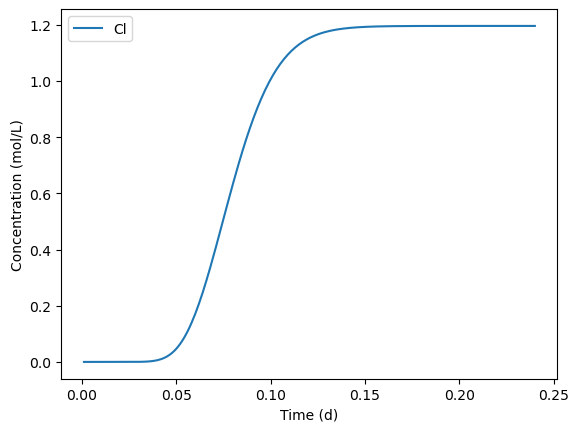

In [48]:
# Plot concentration results timeseries at last cell 
mf6_results_df = pd.DataFrame(
    conc[:,0,0,-1], # select timeseries at last cell
    index=times,
    columns=[component],
)
mf6_results_df.plot(xlabel='Time (d)', ylabel='Concentration (mol/L)')

ex6 Ca gwt_ca (240, 2, 1, 80)
ex6 K gwt_k (240, 2, 1, 80)


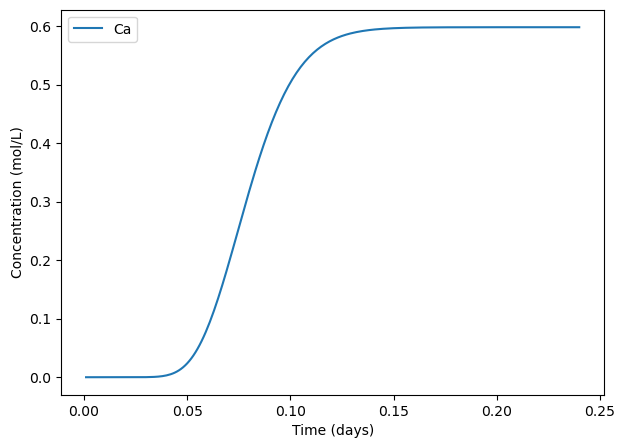

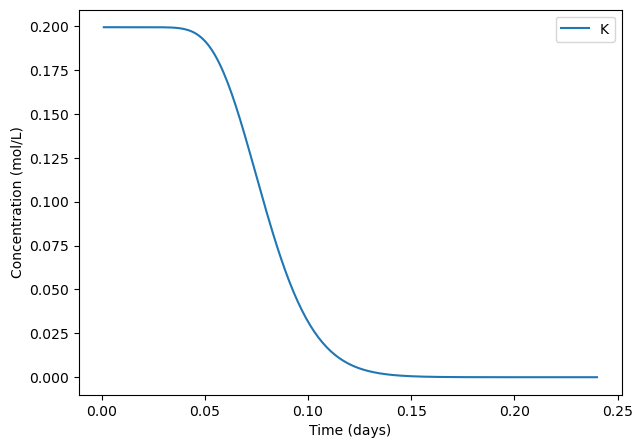

In [49]:
# Confirm breakthrough curves for other components mirror Cl
components = ['Ca', 'K']
for component in components:
    gwt_model_name = component_gwt_model_dict[component]
    conc = sim.get_model(gwt_model_name).output.concentration().get_alldata()
    print(sim_name, component, gwt_model_name, conc.shape)
    fig = plt.figure(figsize=(7, 5))
    plt.plot(times, conc[:,0,0,-1],label=component)
    plt.ylabel('Concentration (mol/L)')
    plt.xlabel('Time (days)')
    plt.legend()

# Create PhreeqcRM YAML config file from YAMLPhreeqcRM module

The [**YAMLPhreeqcRM**](https://usgs-coupled.github.io/phreeqcrm/classYAMLPhreeqcRM.html) module is a helper class to programmatically write a YAML configuration file for PhreeqcRM.

This section is based on the [`phreeqcrm/swig/python/ex11-advect/ex11-advect.ipynb`](https://github.com/usgs-coupled/phreeqcrm/blob/master/swig/python/ex11-advect/ex11-advect.ipynb) example notebook

## Initialize YAML file and set grid size

In [50]:
# Create YAMLPhreeqcRM document object
yrm = phreeqcrm.YAMLPhreeqcRM()

In [51]:
# Number of grid cells, read in from the Modflow 6 simulation (above)
nxyz

160

In [52]:
# Set GridCellCount
yrm.YAMLSetGridCellCount(nxyz)  
    # Number of cells for the PhreeqcRM instance

## Set Properties

In [53]:
# Set these parameters here, 
# to match order in `Mup3d._write_phreeqc_init_file()`
yrm.YAMLThreadCount(1)
yrm.YAMLSetComponentH2O(False)
yrm.YAMLUseSolutionDensityVolume(False)

In [54]:
# From `Mup3d._write_phreeqc_init_file()`

# Open files for phreeqcrm logging
yrm.YAMLSetFilePrefix(str(phreeqc_output_prefix))
yrm.YAMLOpenFiles()

In [55]:
yrm.YAMLSetErrorHandlerMode(1)   
    # 0 (default), return to calling program with an error return code; 
    # 1, throw an exception; 2, attempt to exit gracefully
# yrm.YAMLSetComponentH2O(False)              
    # True (default), excess H, excess O, and water are included in the 
    #   component list (require less accuracy in transport); 
    # False, total H and O are included in the component list (requires 
    #   transportresults to be accurate to eight or nine significant 
    #   digits)
yrm.YAMLSetRebalanceFraction(0.5)           
    # 0.5 (default); 
    # 0, eliminate load rebalancing; 
    # 1, maximum load rebalancing setting; 
    # Less than 1 recommended to avoid too many cells transferred at one 
    #   iteration
yrm.YAMLSetRebalanceByCell(True)            
    # True (default), individual cell times are used in rebalancing; 
    # False, average times are used in rebalancing
# yrm.YAMLUseSolutionDensityVolume(False)     
    # True, use solution density and volume as calculated by PHREEQC; 
    # False, use solution density set by SetDensityUser and the volume 
    #   determined by the product of  SetSaturationUser, SetPorosity, 
    #   and SetRepresentativeVolume
yrm.YAMLSetPartitionUZSolids(False)         
    # True, the fraction of solids and gases available for reaction is 
    #   equal to the saturation; 
    # False (default), all solids and gases are reactive regardless of 
    #   saturation

## Set Units

In [56]:
# Set concentration units
yrm.YAMLSetUnitsSolution(2)
    # 1, mg/L; 2, mol/L; 3, mass fraction, kg/kgs
yrm.YAMLSetUnitsPPassemblage(1) # pure phase assemblages (equilibrium phases)
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock
yrm.YAMLSetUnitsExchange(1)
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock
yrm.YAMLSetUnitsSurface(1)
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock
yrm.YAMLSetUnitsGasPhase(1)
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock
yrm.YAMLSetUnitsSSassemblage(1)  # solid-solution assemblages
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock
yrm.YAMLSetUnitsKinetics(1)
    # 0, mol/L cell; 1, mol/L water; 2 mol/L rock

In [57]:
# Set conversion from seconds to user units (days);
#   Only affects one print statement
time_conversion = 1.0 / 86400.0
# yrm.YAMLSetTimeConversion(time_conversion)      
    # Factor to convert seconds to user time units

## Set Initial Conditions

In [58]:
# Set these parameters here, 
# to match order in `Mup3d._write_phreeqc_init_file()`

# Set initial porosity
por = [1.0] * nxyz # mf6 handles porosity. Set to 1.
yrm.YAMLSetPorosity(por)                        
    # Porosity, unitless, for each reaction cell as an array of size 
    #   nxyz

In [59]:
# From `Mup3d._write_phreeqc_init_file()`

print_chemistry_mask = [1]*nxyz
yrm.YAMLSetPrintChemistryMask(print_chemistry_mask)
yrm.YAMLSetPrintChemistryOn(False, True, False)  # workers, initial_phreeqc, utility

In [60]:
# Set representative volume
rv = [1] * nxyz                                 
yrm.YAMLSetRepresentativeVolume(rv)             
    # Representative volumes, in liters, of each reaction cell as an 
    #   array of size nxyz. Default is 1.0 liter.

# Set initial density
density = [1.0] * nxyz
yrm.YAMLSetDensityUser(density)                 
    # Density for each reaction cell as an array of size nxyz

# Set initial porosity
# por = [0.2] * nxyz
# yrm.YAMLSetPorosity(por)                        
    # Porosity, unitless, for each reaction cell as an array of size 
    #   nxyz

# Set initial saturation
sat = [1] * nxyz
yrm.YAMLSetSaturationUser(sat)                  
    # Saturation fraction for each reaction cell ranging from 0 to 1 as 
    #   an array of size nxyz

## Load Database and Run Input File

In [61]:
# Load database
yrm.YAMLLoadDatabase(str(phreeqc_database_filepath))          
    # String containing the database name for all IPhreeqc 
    #   instances--workers, InitialPhreeqc, and Utility

# Run file to define solutions and reactants for initial conditions, 
#   selected output
workers = True             
    # Worker instances do the reaction calculations for transport
initial_phreeqc = True     
    # InitialPhreeqc instance accumulates initial and boundary 
    #   conditions
utility = True             
    # Utility instance is available for processing
chemistry_name = str(phreeqc_input_filepath)
    # Filepath to the PHREEQC input file (*.pqi)
yrm.YAMLRunFile(workers, initial_phreeqc, utility, chemistry_name)        
    # YAMLRunFile runs a PHREEQC input file. The first three arguments 
    #   determine which IPhreeqc instances will run the file


## Clear contents of Workers and Utility

In [62]:
# Run PHREEQC input string to delete all inputs
initial_phreeqc = False    
    # False Indicates InitialPhreeqc will not run the string
input = "DELETE; -all"     
    # String containing PHREEQC input that clears contents for the 
    #   instances that run
yrm.YAMLRunString(workers, initial_phreeqc, utility, input)       
    # YAMLRunString runs a PHREEQC input string. The first three 
    #   arguments determine which IPhreeqc instances will run the string

# Allow standard output variables to be available through BMI GetValue
output_vars = "AddOutputVars"                       
    # A string value that includes or excludes variables from 
    #   GetOutputVarNames, GetValue, and other BMI methods
include_vars = "true"                               
    # A string value that can be "false", "true", or a list of items to 
    #   be included as accessible variables
yrm.YAMLAddOutputVars(output_vars, include_vars)    
    # AddOutputVars allows selection of sets of output variables that 
    #   are available through the BMI method GetValue

## Find Components and Transfer Definitions

In [63]:
# Determine number of components to transport
yrm.YAMLFindComponents()    
    # YAMLFindComponents accumulates a list of elements that have been 
    #   defined in a solution or any other reactant (EQUILIBRIUM_PHASE, 
    #   KINETICS, and others). The list is the set of components that 
    #   needs to be transported

# initial solutions
initial_solutions = [1] * nxyz
yrm.YAMLInitialSolutions2Module(initial_solutions)      
    # SOLUTION definitions, as an array of size nxyz, from the 
    #   InitialPhreeqc instance to be transferred to the reaction-module
    #   workers

# initial exchanges
initial_exchanges = [1] * nxyz
yrm.YAMLInitialExchanges2Module(initial_exchanges)      
    # EXCHANGE definitions, as an array of size nxyz, from the 
    #   InitialPhreeqc instance to be transferred to the reaction-module
    #   workers

TODO: ADD USER_PUNCH from `ex4/mf6rtm/phinp.dat` to .pqi file to configure outputs for plotting
In mf6rtm, this is done by `Mup3d.generate_phreeqc_script()`


In [64]:
# From `Mup3d._write_phreeqc_init_file()`

yrm.YAMLRunCells()
# Initial equilibration of cells
time = 0.0
yrm.YAMLSetTime(time)

## Write YAML File

In [65]:
yrm.WriteYAMLDoc(str(phreeqc_config_filepath))      
    # String containing file name where YAML document will be written

In [66]:
# Confirm that the file was created
phreeqc_config_filepath.exists()

True

# Run rtm using PhreeqcRM YAML

### Initialize PhreeqcRM interface with selected YAML

In [67]:
# Use this YAML
phreeqc_config_filepath.name

'ex6_advect3d_rm.yaml'

In [68]:
# Initialize phreeqcrm interface
rm = mf6rtm.PhreeqcBMI(str(phreeqc_config_filepath))
type(rm)

Processing initial chemistry configuration


mf6rtm.simulation.phreeqcbmi.PhreeqcBMI

In [69]:
# Confirm concentrations
rm.GetConcentrations()

array([1.10679332e+02, 1.10679332e+02, 1.10679332e+02, ...,
       9.96999419e-04, 9.96999419e-04, 9.96999419e-04], shape=(1280,))

### Initilize ModflowAPI interface

In [70]:
# initialize the interfaces
wd = mf6_inout_path
# dll = 'libmf6'

mf6 = mf6rtm.Mf6API(wd, dll)

In [71]:
# Save list of outputs for potential use later
output_var_names = mf6.get_output_var_names()
input_var_names = mf6.get_input_var_names()

In [72]:
# Get list of modflow input varables with concentration data ('/X' or '/XOLD')
gwt_conc_var_names = []
for model_name in gwt_model_names:
    gwt_conc_var_names += [var for var in input_var_names if f'{model_name.upper()}/X' in var]
gwt_conc_var_names


['GWT_H/X',
 'GWT_H/XOLD',
 'GWT_O/X',
 'GWT_O/XOLD',
 'GWT_CH/XOLD',
 'GWT_CH/X',
 'GWT_CA/X',
 'GWT_CA/XOLD',
 'GWT_CL/XOLD',
 'GWT_CL/X',
 'GWT_K/X',
 'GWT_K/XOLD',
 'GWT_N/X',
 'GWT_N/XOLD',
 'GWT_NA/X',
 'GWT_NA/XOLD']

In [73]:
conc_var_name = gwt_conc_var_names[-2]
conc_var_name

'GWT_NA/X'

In [74]:
# Get info from the BMI functions exposed by modflowapi
mf6.get_var_rank(conc_var_name)

1

In [75]:
mf6.get_value(conc_var_name)

array([0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703984,
       0.99703984, 0.99703984, 0.99703984, 0.99703984, 0.99703

In [76]:
# This BMI function is not implementned in modflowapi for DISV
# mf6.get_grid_rank(1)

### Initialize & Run MF6RTM coupling interface

In [77]:
# mf6rtm needs a toml config file to read optional arguments
# this can be created through mup3d or we can do one here with
config = mf6rtm.config.MF6RTMConfig()
# let's save the file
config.save_to_file(Path(wd/"mf6rtm.toml"))

# let's print the arguments
# it telling us that we want to run reactions in all timesteps
print(config)

MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Reactions calculated at all time steps


In [78]:
rtm = mf6rtm.Mf6RTM(wd, mf6, rm)

In [79]:
# Get PHREEQC component to GWT model dictionary
# created using mf6rtm functions
rtm.component_model_dict

{'H': 'gwt_h',
 'O': 'gwt_o',
 'Charge': 'gwt_ch',
 'Ca': 'gwt_ca',
 'Cl': 'gwt_cl',
 'K': 'gwt_k',
 'N': 'gwt_n',
 'Na': 'gwt_na'}

In [80]:
# Confirm that all gwt models have been matched to a reactive component
rtm.conservative_transport_models

[]

In [81]:
# confirm it matches what we created manually above
assert rtm.component_model_dict == component_gwt_model_dict

### RTM Solve

Run the coupled Reactive Transport Model!

In [82]:
%%prun -q -D mf6rtm_sim.prof
# View performance profile from terminal 
# with `snakeviz benchmark/sandbox/mf6rtm_sim.prof`
rtm.solve()

Starting Solution at 2026-05-28 14:27:22
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   4.20e-05 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   2.64e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   3.65e-05 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.91e-04 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   3.65e-05 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.89e-04 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   3.91e-05 sec
Reactions       | Stress period:  1     | Time step:      4          | Completed in :  0 min   1.82e-04 sec
Transport       | Stress period:  1     | Time step:      5          | Completed in :  0 min   

FloPy: Elapsed run time:  1.007 Seconds

MF6RTM: Reactive transport solution finished at 2025-05-23 16:18:06 --- it took:   0.098398 mins =  (5.9 seconds)

Coupling to PHREEQC took 5.9x longer!

# Read & Plot Results

## Chemistry Outputs in memory

In [83]:
headings = rtm.phreeqcbmi.GetSelectedOutputHeadings()
print(headings.shape)
headings

(6,)


array(['time_d', 'cell', 'Na', 'Ca', 'K', 'Cl'], dtype='<U6')

In [84]:
# number of timesteps 'nstp'
nstp

array([240])

In [85]:
rtm.phreeqcbmi.GetSelectedOutput().shape

(960,)

In [86]:
rtm.selected_output._sout_k.shape

(6, 160)

In [87]:
rtm.ctime

0.24

In [88]:
rtm.phreeqcbmi.soutdf

,time_d,cell,Na,Ca,K,Cl
0,0.001,0.0,9.433848e-04,5.030468e-07,2.556064e-04,0.000340
1,0.001,1.0,9.769026e-04,1.390030e-07,2.228157e-04,0.000161
2,0.001,2.0,9.917877e-04,4.129027e-08,2.081256e-04,0.000062
3,0.001,3.0,9.970369e-04,1.395499e-08,2.029308e-04,0.000023
4,0.001,4.0,9.989148e-04,4.982616e-09,2.010708e-04,0.000008
...,...,...,...,...,...,...
155,0.241,155.0,1.112117e-09,5.999933e-04,1.413060e-08,0.001200
156,0.241,156.0,1.510488e-09,5.999905e-04,1.940967e-08,0.001200
157,0.241,157.0,1.996602e-09,5.999870e-04,2.590335e-08,0.001200
158,0.241,158.0,2.536457e-09,5.999831e-04,3.315398e-08,0.001200


In [89]:
rtm.selected_output._current_soutdf

,time_d,cell,Na,Ca,K,Cl
0,0.241,0.0,1.289555e-16,0.0006,1.117158e-15,0.0012
1,0.241,1.0,2.260546e-16,0.0006,1.959698e-15,0.0012
2,0.241,2.0,4.291242e-16,0.0006,3.735002e-15,0.0012
3,0.241,3.0,7.946101e-16,0.0006,6.937741e-15,0.0012
4,0.241,4.0,1.430362e-15,0.0006,1.253545e-14,0.0012
...,...,...,...,...,...,...
155,0.241,155.0,1.112117e-09,0.0006,1.413060e-08,0.0012
156,0.241,156.0,1.510488e-09,0.0006,1.940967e-08,0.0012
157,0.241,157.0,1.996602e-09,0.0006,2.590335e-08,0.0012
158,0.241,158.0,2.536457e-09,0.0006,3.315398e-08,0.0012


In [90]:
sout = rtm.phreeqcbmi.GetSelectedOutput()
# sout

In [91]:
i = 0
var_name = headings[i]
print(var_name)
sout[i : i + nxyz]

time_d


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

## Read Output files

In [92]:
output_filepath = mf6_inout_path / 'sout.csv'
output_filepath.exists()

True

In [93]:
## Read mf6rtm results
simapi = pd.read_csv(
    output_filepath, 
    sep = ',', 
    skipinitialspace=True, 
    index_col=[0],
)
simapi.info()
simapi.index.name

<class 'pandas.core.frame.DataFrame'>
Index: 38400 entries, 0.001 to 0.241
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cell    38400 non-null  float64
 1   Na      38400 non-null  float64
 2   Ca      38400 non-null  float64
 3   K       38400 non-null  float64
 4   Cl      38400 non-null  float64
dtypes: float64(5)
memory usage: 1.8 MB


'time_d'

In [94]:
simapi.cell.max()

159.0

In [95]:
# create table for last cell representing the column effluent
mf6df = simapi[simapi.cell==simapi.cell.max()]
mf6df

,cell,Na,Ca,K,Cl
time_d,,,,,
0.001,159.0,9.999965e-04,6.439126e-24,1.999990e-04,9.830537e-21
0.003,159.0,9.999965e-04,1.308112e-23,1.999990e-04,1.937550e-19
0.004,159.0,9.999965e-04,2.000832e-23,1.999990e-04,2.414963e-18
0.005,159.0,9.999965e-04,2.630822e-23,1.999990e-04,2.127749e-17
0.006,159.0,9.999965e-04,3.523488e-23,1.999990e-04,1.483393e-16
...,...,...,...,...,...
0.237,159.0,4.671677e-09,5.999686e-04,6.014132e-08,1.200001e-03
0.238,159.0,4.189243e-09,5.999718e-04,5.419404e-08,1.200001e-03
0.239,159.0,3.756597e-09,5.999747e-04,4.883568e-08,1.200001e-03


## Plot

<Axes: title={'center': 'ex 6 disv results'}, xlabel='Time (d)', ylabel='Concentration (mmol L$^{-1}$)'>

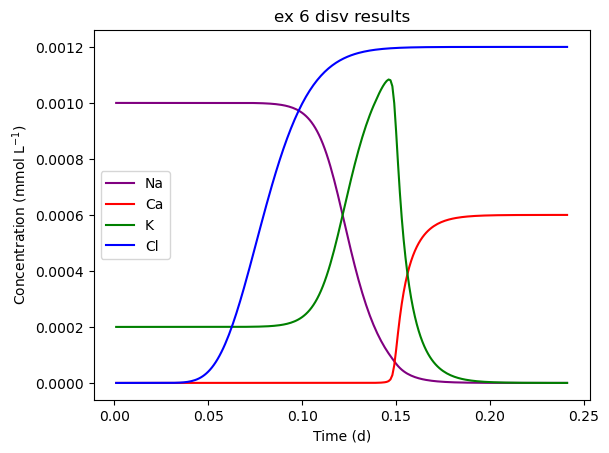

In [96]:
# Create interactiveHoloViz plot
mf6df.plot(
    y=['Na', 'Ca', 'K', 'Cl'], 
    kind='line', 
    xlabel='Time (d)', 
    ylabel='Concentration (mmol L$^{-1}$)',
    title='ex 6 disv results',
    color=['purple', 'red', 'green', 'blue']
)

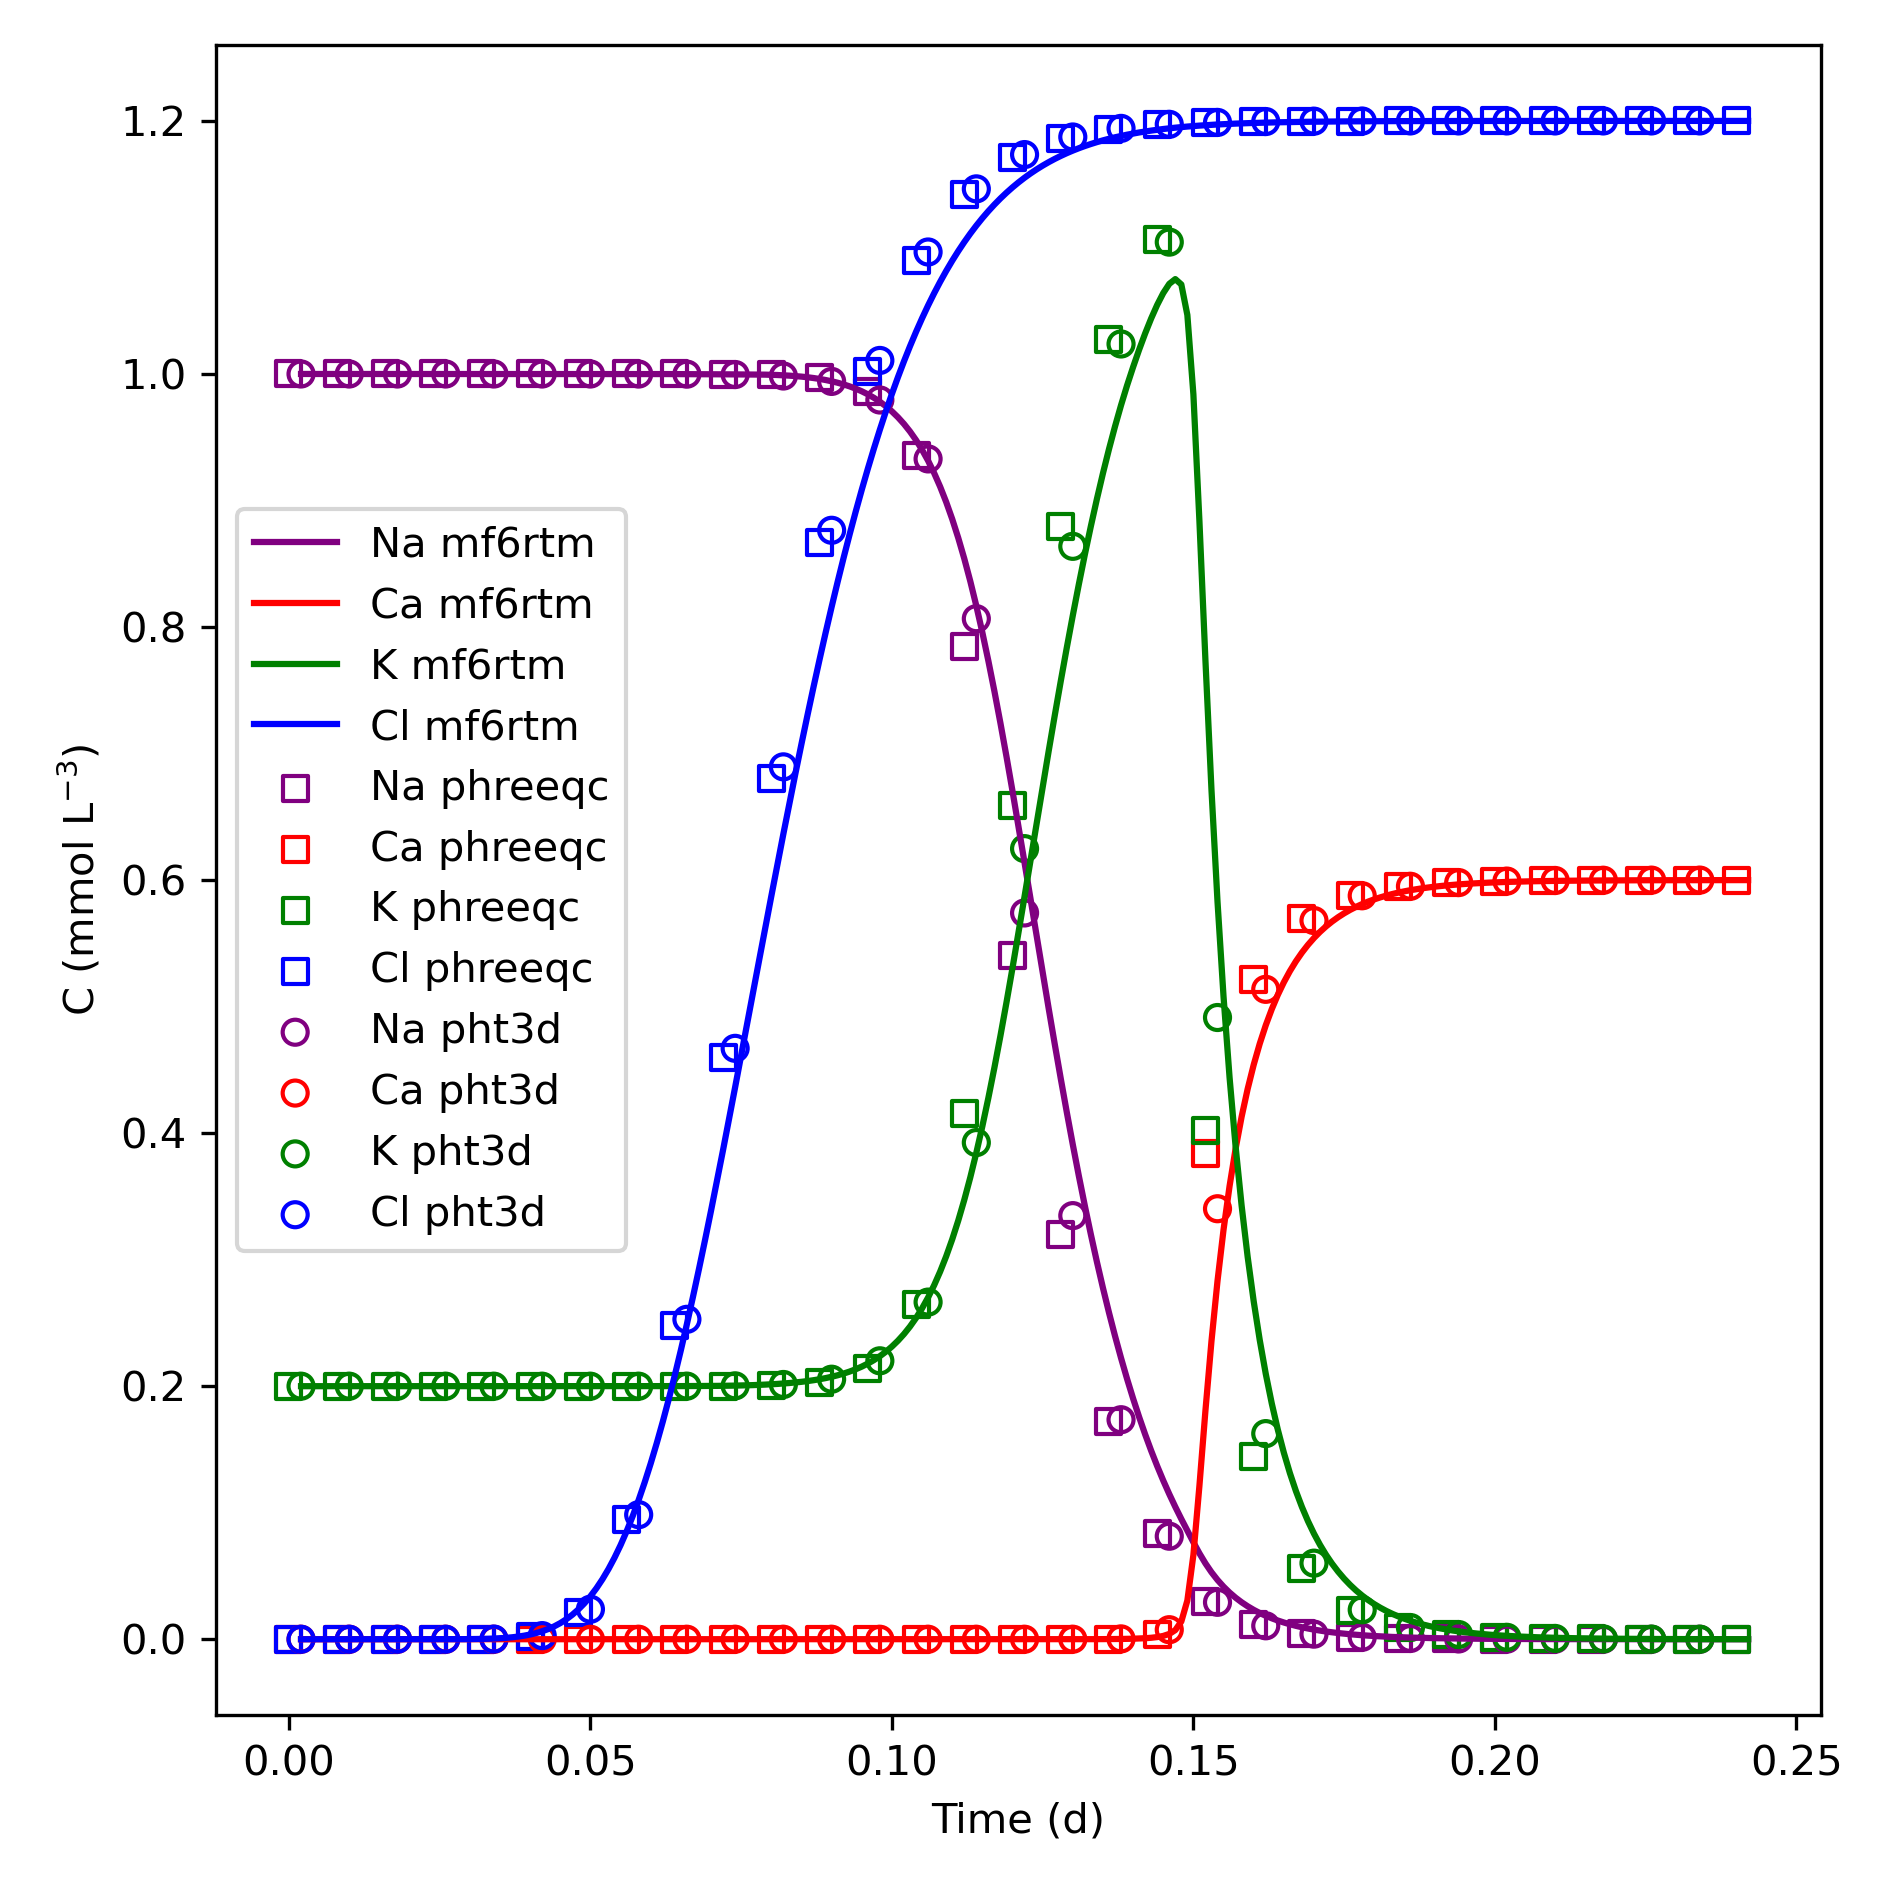

In [97]:
# Compare to 1D results from Example 4
ex4_plot_filepath = working_dir / 'ex4.png'
if ex4_plot_filepath.exists():
   ex4_plot = Image(
      filename=ex4_plot_filepath,
      width=600,
   )
else:
   print('Run Example 4 to create ex4.png')
ex4_plot

# END

# Sandbox

## Test reshaping & transfer methods

### Get Arrays

In [98]:
rtm.charge_offset

0.0

In [99]:
components = rtm.component_model_dict
ncomps = len(components)
nxyz = rtm.nxyz
ncomps, nxyz, ncomps*nxyz

(8, 160, 1280)

In [100]:
# 1D concentration array from phreeqc of length (ncomps*nxyz)
c_dbl_vect = rtm._get_cdlbl_vect().copy()
c_dbl_vect

array([1.10684001e+02, 1.10684000e+02, 1.10684000e+02, ...,
       1.99069538e-09, 2.52895276e-09, 3.01147550e-09], shape=(1280,))

In [101]:
# reshape to 2D array of shape (ncomps, nxyz)
mf6_conc_array = np.reshape(c_dbl_vect, (ncomps, nxyz))
mf6_conc_array

array([[ 1.10684001e+02,  1.10684000e+02,  1.10684000e+02, ...,
         1.10684000e+02,  1.10684000e+02,  1.10684000e+02],
       [ 5.53420859e+01,  5.53420858e+01,  5.53420857e+01, ...,
         5.53420857e+01,  5.53420857e+01,  5.53420857e+01],
       [-1.31098771e-09, -1.31098771e-09, -1.31098770e-09, ...,
        -1.29297561e-08, -2.96342294e-08, -7.03429502e-08],
       ...,
       [ 1.11385278e-15,  1.95390007e-15,  3.72395154e-15, ...,
         2.58267105e-08,  3.30558926e-08,  3.95405160e-08],
       [ 2.20825349e-17,  3.82911483e-17,  7.30006483e-17, ...,
         2.39521851e-10,  3.03285468e-10,  3.61518311e-10],
       [ 1.28573935e-16,  2.25385827e-16,  4.27854578e-16, ...,
         1.99069538e-09,  2.52895276e-09,  3.01147550e-09]],
      shape=(8, 160))

In [102]:
# %%timeit
# np.reshape(c_dbl_vect, (ncomps, nxyz))
# # 443 ns ± 10.7 ns

In [103]:
# %%timeit
# np.reshape(mf6rtm.utils.concentration_l_to_m3(c_dbl_vect), (ncomps, nxyz))
# # 1.09 μs ± 18.4 ns, so converting units increases conversion by 2.4x

In [104]:
# %%timeit
# # check time to return same shape
# np.reshape(mf6_conc_array, (ncomps, nxyz))
# # 462 ns ± 2.76 ns, same time! 
# # NOTE: good idea to remove needless reshaping!

In [105]:
# Confirm identical
mf6_conc_array_previous = rtm.previous_iteration_conc.copy()
mf6_conc_array_previous == mf6_conc_array

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(8, 160))

In [106]:
# Reshape to 1D conc array of length (ncomps*nxyz)
rm_conc_array = mf6_conc_array.flatten()
rm_conc_array == c_dbl_vect

array([ True,  True,  True, ...,  True,  True,  True], shape=(1280,))

In [107]:
# %%timeit
# mf6_conc_array.flatten()
# # 420 ns ± 9.24 ns

In [108]:
# %%timeit
# mf6_conc_array.ravel() # returns view (when possible)
# # 52.3 ns ± 0.371 ns, 8x faster and less memory

In [109]:
mf6_conc_array.ravel() == c_dbl_vect

array([ True,  True,  True, ...,  True,  True,  True], shape=(1280,))

### `rm_concs_to_dict()`

In [110]:
def rm_concs_to_dict(rm_conc_array, components, grid_size):
    component_concs_dict = {}
    component_concs_array = rm_conc_array.reshape((len(components), grid_size))
    for i, component in enumerate(components):
        component_concs_dict[component] = component_concs_array[i]
    return component_concs_dict
# NOTE: this function is 2-3x faster than alternate approaches tested for GSSHA+PHREEQC coupling

In [111]:
component_concs_dict = rm_concs_to_dict(rm_conc_array, components, nxyz)
component_concs_dict.keys()

dict_keys(['H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na'])

In [112]:
# %%timeit
# component_concs_dict = rm_concs_to_dict(rm_conc_array, components, nxyz)
# # 1.04 μs ± 16.8 ns

### `conc_dict_to_rm_array()`

In [113]:
def conc_dict_to_rm_array(component_concs_dict):
    # This approach works because since python 3.7, dictionaries preserve insertion order
    rm_conc_array = np.concatenate(list(component_concs_dict.values())).flatten()
    return rm_conc_array
# NOTE: this function is 25% faster than alternate approaches tested for GSSHA+PHREEQC coupling

In [114]:
# %%timeit
# conc_dict_to_rm_array(component_concs_dict)
# # 1.32 μs ± 11.9 ns

In [115]:
conc_dict_to_rm_array(component_concs_dict).shape

(1280,)

In [116]:
# Test round trip transformations
conc_dict_to_rm_array(component_concs_dict) == c_dbl_vect

array([ True,  True,  True, ...,  True,  True,  True], shape=(1280,))

### `get_conc_change_mask()`

In [117]:
ci = rtm.current_iteration_conc.copy()
ck = rtm.previous_iteration_conc.copy()
ci.shape, ck.shape

((8, 160), (8, 160))

In [118]:
relative_change = np.abs((ci-ck)/ci)
relative_change

array([[1.31472617e-16, 1.31472617e-16, 1.31472617e-16, ...,
        1.31472617e-16, 0.00000000e+00, 1.31472617e-16],
       [1.31472414e-16, 1.31472414e-16, 1.31472414e-16, ...,
        1.31472414e-16, 0.00000000e+00, 1.31472414e-16],
       [3.52995892e-10, 4.42736515e-10, 5.42084042e-10, ...,
        2.56243776e-09, 1.53909205e-09, 7.56087746e-10],
       ...,
       [1.01346328e-02, 1.01325395e-02, 1.01299644e-02, ...,
        9.94875358e-03, 9.95306399e-03, 9.95586178e-03],
       [5.19845387e-13, 5.14052417e-13, 5.18871354e-13, ...,
        1.32613101e-15, 2.09464276e-15, 2.05011421e-15],
       [2.17570685e-03, 2.17225882e-03, 2.17365182e-03, ...,
        2.07272735e-03, 2.07183258e-03, 2.07152197e-03]], shape=(8, 160))

In [119]:
# threshold = 0.0
# threshold = 1e-10
threshold = 1e-15
diffmask = relative_change < threshold
diffmask

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(8, 160))

In [120]:
np.where(diffmask, 0, 1).sum(axis=0)

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 5,
       4, 5, 4, 4, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 5, 4, 5, 4, 5, 5,
       5, 4, 5, 4, 4, 5, 4, 5, 5, 5, 4, 4, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 4, 4, 5, 5, 5, 5, 5, 5, 4,
       4, 5, 4, 5, 5, 5, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 4, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 5,
       4, 4, 5, 5, 5, 5])

In [121]:
# %%timeit
# a = np.array([10, 20, 30])
# b = np.array([2, 0, 5])
# # Returns 0 where b is 0
# result = np.divide(a, b, out=np.zeros_like(a, dtype=float), where=b!=0)
# # 2.5 μs ± 37.9 ns, 2x faster than alternative below

In [122]:
# %%timeit
# a = np.array([10, 20, 30])
# b = np.array([2, 0, 5])
# result = a/b
# # 1.44 μs ± 16.1 ns, but returns `inf`

In [123]:
# %%timeit
# a = np.array([10, 20, 30])
# b = np.array([2, 0, 5])
# result = a/b
# np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
# # 5.64 μs ± 46.7 ns

In [124]:
rtm.mf6api.get_var_address("X", gwt_model_name)

'GWT_K/X'

In [125]:
# %%timeit
# rtm.mf6api.get_var_address("X", gwt_model_name)
# # 1.64 μs ± 39 ns 

In [126]:
# %%timeit
# f"{gwt_model_name}/X"
# # 41.4 ns ± 1.63 ns, 40x faster

In [127]:
# %%timeit
# mf6rtm.utils.concentration_l_to_m3(rtm.min_concentration)
# # 54.5 ns ± 0.362 ns

In [128]:
# %%timeit
# rtm.min_concentration
# # 22.7 ns ± 0.138 ns

# END